## Import Library

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.inspection import permutation_importance

## Load Dataset

In [ ]:
path = kagglehub.dataset_download("buntyshah/auto-insurance-claims-data")
df = pd.read_csv(path + "/insurance_claims.csv")

Using Colab cache for faster access to the 'auto-insurance-claims-data' dataset.


In [ ]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [ ]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


## Data Cleaning & Processing

In [ ]:
col_to_drop = [c for c in df.columns if df[c].nunique() >900]
col_to_drop.append('_c39')
col_to_drop

['policy_number',
 'policy_bind_date',
 'policy_annual_premium',
 'insured_zip',
 'incident_location',
 '_c39']

In [ ]:
col_to_drop.remove('policy_annual_premium')

df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])
df['policy_bind_date_year'] = df['policy_bind_date'].dt.year
df['policy_bind_date_month'] = df['policy_bind_date'].dt.month
df['policy_bind_date_day'] = df['policy_bind_date'].dt.day
df['policy_bind_date_dayofweek'] = df['policy_bind_date'].dt.dayofweek

df['incident_date'] = pd.to_datetime(df['incident_date'])
df['incident_date_year'] = df['incident_date'].dt.year
df['incident_date_month'] = df['incident_date'].dt.month
df['incident_date_day'] = df['incident_date'].dt.day
df['incident_date_dayofweek'] = df['incident_date'].dt.dayofweek
col_to_drop.append('incident_date')

df = df.drop(columns=col_to_drop)

In [ ]:
df['authorities_contacted'] = df['authorities_contacted'].fillna("None")

In [ ]:
cat_cols = list(df.select_dtypes(include=['object']).columns)
cat_cols.remove('fraud_reported')
cat_cols.append('policy_bind_date_month')
cat_cols.append('policy_bind_date_day')
cat_cols.append('policy_bind_date_dayofweek')
cat_cols.append('incident_hour_of_the_day')
cat_cols.append('incident_date_month')
cat_cols.append('incident_date_day')
cat_cols.append('incident_date_dayofweek')

num_cols = list(df.select_dtypes(include=['int64','float64']).columns)

df[cat_cols] = df[cat_cols].astype('category')

df['fraud_reported'] = df['fraud_reported'].map({'Y':1,'N':0})

<Axes: xlabel='fraud_reported'>

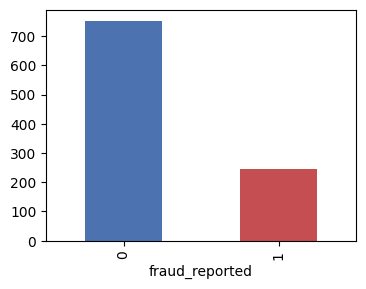

In [ ]:
df['fraud_reported'].value_counts().plot(kind='bar', color=['#4C72B0', '#C44E52'], figsize=(4,3))

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

In [ ]:
X = df.drop(columns=['fraud_reported'])
y = df['fraud_reported']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Build & Evaluate Model

In [ ]:
knn_base = KNeighborsClassifier(n_neighbors=5)
logr_base = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
nb_base = GaussianNB()
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', knn_base)])
logr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', logr_base)])
nb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', nb_base)])
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', dt_base)])
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', rf_base)])

knn_pipeline.fit(X_train, y_train)
logr_pipeline.fit(X_train, y_train)
nb_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

knn_pred = knn_pipeline.predict(X_test)
logr_pred = logr_pipeline.predict(X_test)
nb_pred = nb_pipeline.predict(X_test)
dt_pred = dt_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

knn_pred_proba = knn_pipeline.predict_proba(X_test)
logr_pred_proba = logr_pipeline.predict_proba(X_test)
nb_pred_proba = nb_pipeline.predict_proba(X_test)
dt_pred_proba = dt_pipeline.predict_proba(X_test)
rf_pred_proba = rf_pipeline.predict_proba(X_test)

In [ ]:
def evaluate_model(y_true, y_pred, y_pred_proba, model: str):
  accuracy = accuracy_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  roc_auc = roc_auc_score(y_true, y_pred_proba[:,1])
  average_precision = average_precision_score(y_true, y_pred_proba[:,1])
  print('='*50)
  print(f'Model: {model}')
  print(f'Accuracy: {round(accuracy,2)}')
  print(f'F1: {round(f1,2)}')
  print(f'Recall: {round(recall,2)}')
  print(f'ROC-AUC: {round(roc_auc,4)}')
  print(f'PR-AUC: {round(average_precision,4)}')
  return {
      'Model': model,
      'Accuracy': accuracy,
      'F1': f1,
      'Recall': recall,
      'ROC-AUC': roc_auc,
      'PR-AUC': average_precision
      }


In [ ]:
results = []
knn_eval = evaluate_model(y_test, knn_pred, knn_pred_proba, 'KNN')
lr_eval = evaluate_model(y_test, logr_pred, logr_pred_proba, 'Logistic Regression')
nb_eval = evaluate_model(y_test, nb_pred, nb_pred_proba, 'Naive Bayes')
dt_eval = evaluate_model(y_test, dt_pred, dt_pred_proba, 'Decision Tree')
rf_eval = evaluate_model(y_test, rf_pred, rf_pred_proba, 'Random Forest');

results.append(knn_eval)
results.append(lr_eval)
results.append(nb_eval)
results.append(dt_eval)
results.append(rf_eval)

Model: KNN
Accuracy: 0.68
F1: 0.18
Recall: 0.13
ROC-AUC: 0.5371
PR-AUC: 0.2894
Model: Logistic Regression
Accuracy: 0.76
F1: 0.58
Recall: 0.6
ROC-AUC: 0.8001
PR-AUC: 0.5175
Model: Naive Bayes
Accuracy: 0.61
F1: 0.43
Recall: 0.55
ROC-AUC: 0.6846
PR-AUC: 0.4552
Model: Decision Tree
Accuracy: 0.73
F1: 0.5
Recall: 0.49
ROC-AUC: 0.6592
PR-AUC: 0.3949
Model: Random Forest
Accuracy: 0.72
F1: 0.3
Recall: 0.22
ROC-AUC: 0.8217
PR-AUC: 0.5281


## Hyperparameters Tuning



In [ ]:
knn_params = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['minkowski', 'euclidean', 'manhattan']
}

knn_search = GridSearchCV(
    knn_pipeline,
    knn_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

knn_search.fit(X_train, y_train)
best_knn = knn_search.best_estimator_
best_knn_pred = best_knn.predict(X_test)
best_knn_pred_proba = best_knn.predict_proba(X_test)

In [ ]:
logreg_params = [
    {
        'classifier__penalty': ['l2'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['lbfgs', 'saga'],
        'classifier__max_iter': [1000]
    },
    {
        'classifier__penalty': ['l1'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__max_iter': [1000]
    }
]

logreg_search = GridSearchCV(
    logr_pipeline,
    logreg_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

logreg_search.fit(X_train, y_train)
best_logreg = logreg_search.best_estimator_
best_logreg_pred = best_logreg.predict(X_test)
best_logreg_pred_proba = best_logreg.predict_proba(X_test)

In [ ]:
nb_params = {
    'classifier__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

nb_search = GridSearchCV(
    nb_pipeline,
    nb_params,
    cv = 5,
    scoring = 'f1',
    n_jobs=-1
)

nb_search.fit(X_train, y_train)
best_nb = nb_search.best_estimator_
best_nb_pred = best_nb.predict(X_test)
best_nb_pred_proba = best_nb.predict_proba(X_test)

In [ ]:
dt_params = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [5, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4, 10]
}

dt_search = GridSearchCV(
    dt_pipeline,
    dt_params,
    cv = 5,
    scoring = 'f1',
    n_jobs=-1
)

dt_search.fit(X_train, y_train)
best_dt = dt_search.best_estimator_
best_dt_pred = best_dt.predict(X_test)
best_dt_pred_proba = best_dt.predict_proba(X_test)

In [ ]:
rf_params = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=50,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)
best_rf_pred_proba = best_rf.predict_proba(X_test)

In [ ]:
tuned_knn_eval = evaluate_model(y_test, best_knn_pred, best_knn_pred_proba, 'Tuned KNN')
tuned_lr_eval = evaluate_model(y_test, best_logreg_pred, best_logreg_pred_proba, 'Tuned Logistic Regression')
tuned_nb_eval = evaluate_model(y_test, best_nb_pred, best_nb_pred_proba, 'Tuned Naive Bayes')
tuned_dt_eval = evaluate_model(y_test, best_dt_pred, best_dt_pred_proba, 'Tuned Decision Tree')
tuned_rf_eval = evaluate_model(y_test, best_rf_pred, best_rf_pred_proba, 'Tuned Random Forest')

results.append(tuned_knn_eval)
results.append(tuned_lr_eval)
results.append(tuned_nb_eval)
results.append(tuned_dt_eval)
results.append(tuned_rf_eval)

Model: Tuned KNN
Accuracy: 0.69
F1: 0.32
Recall: 0.27
ROC-AUC: 0.5757
PR-AUC: 0.3403
Model: Tuned Logistic Regression
Accuracy: 0.83
F1: 0.74
Recall: 0.87
ROC-AUC: 0.8308
PR-AUC: 0.5424
Model: Tuned Naive Bayes
Accuracy: 0.61
F1: 0.43
Recall: 0.55
ROC-AUC: 0.6846
PR-AUC: 0.4552
Model: Tuned Decision Tree
Accuracy: 0.81
F1: 0.68
Recall: 0.76
ROC-AUC: 0.814
PR-AUC: 0.6037
Model: Tuned Random Forest
Accuracy: 0.84
F1: 0.75
Recall: 0.87
ROC-AUC: 0.8438
PR-AUC: 0.6557


## Results

In [ ]:
df_comparison = pd.DataFrame(results)
df_comparison = df_comparison.sort_values(by='F1', ascending=False)
display(df_comparison)

,Model,Accuracy,F1,Recall,ROC-AUC,PR-AUC
9,Tuned Random Forest,0.840,0.750000,0.872727,0.843762,0.655692
6,Tuned Logistic Regression,0.835,0.744186,0.872727,0.830846,0.542447
8,Tuned Decision Tree,0.805,0.682927,0.763636,0.813981,0.603745
1,Logistic Regression,0.760,0.578947,0.600000,0.800125,0.517532
3,Decision Tree,0.735,0.504673,0.490909,0.659248,0.394895
2,Naive Bayes,0.610,0.434783,0.545455,0.684639,0.455229
7,Tuned Naive Bayes,0.610,0.434783,0.545455,0.684639,0.455229
5,Tuned KNN,0.685,0.322581,0.272727,0.575737,0.340289
4,Random Forest,0.720,0.300000,0.218182,0.821693,0.528096
0,KNN,0.680,0.179487,0.127273,0.537053,0.289386


In [ ]:
encoded_cat_col = best_logreg.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = num_cols + list(encoded_cat_col)

feature_importances_logr = best_logreg.named_steps['classifier'].coef_[0]
feature_importances_df_logr = pd.DataFrame({'Feature': all_features,
                                            'Importance': feature_importances_logr,
                                            'Abs_Importance': np.abs(feature_importances_logr)})
feature_importances_df_logr = feature_importances_df_logr.sort_values(by='Abs_Importance', ascending=False)
display(feature_importances_df_logr.head(5))

,Feature,Importance,Abs_Importance
79,incident_severity_Major Damage,2.511236,2.511236
50,insured_hobbies_chess,2.180355,2.180355
51,insured_hobbies_cross-fit,1.629056,1.629056
4,umbrella_limit,0.180414,0.180414
21,policy_csl_500/1000,-0.158227,0.158227


In [ ]:
feature_importances_dt = best_dt.named_steps['classifier'].feature_importances_
feature_importances_df_dt = pd.DataFrame({'Feature': all_features,
                                            'Importance': feature_importances_dt})
feature_importances_df_dt = feature_importances_df_dt.sort_values(by='Importance', ascending=False)
display(feature_importances_df_dt.head(5))

,Feature,Importance
79,incident_severity_Major Damage,0.493271
50,insured_hobbies_chess,0.214802
51,insured_hobbies_cross-fit,0.181764
28,insured_education_level_MD,0.022924
205,policy_bind_date_dayofweek_1,0.013556


In [ ]:
feature_importances_rf = best_rf.named_steps['classifier'].feature_importances_
feature_importances_df_rf = pd.DataFrame({'Feature': all_features,
                                            'Importance': feature_importances_rf})
feature_importances_df_rf = feature_importances_df_rf.sort_values(by='Importance', ascending=False)
display(feature_importances_df_rf.head(5))

,Feature,Importance
79,incident_severity_Major Damage,0.365189
50,insured_hobbies_chess,0.165494
51,insured_hobbies_cross-fit,0.129694
13,property_claim,0.019571
3,policy_annual_premium,0.015512


In [ ]:
X_test_transformed = best_knn.named_steps['preprocessor'].transform(X_test)
p_importance_knn = permutation_importance(best_knn.named_steps['classifier'],
                                X_test_transformed,
                                y_test,
                                n_repeats=10,
                                random_state=42)
knn_importance = p_importance_knn.importances_mean

feature_importances_df_knn = pd.DataFrame({'Feature': all_features,
                                            'Importance': knn_importance})
feature_importances_df_knn = feature_importances_df_knn.sort_values(by='Importance', ascending=False)
display(feature_importances_df_knn.head(5))

,Feature,Importance
80,incident_severity_Minor Damage,0.0215
235,incident_date_month_1,0.0170
7,incident_hour_of_the_day,0.0155
236,incident_date_month_2,0.0155
6,capital-loss,0.0130


In [ ]:
p_importance_nb = permutation_importance(best_nb.named_steps['classifier'],
                                X_test_transformed,
                                y_test,
                                n_repeats=10,
                                random_state=42)
nb_importance = p_importance_nb.importances_mean

feature_importances_df_nb = pd.DataFrame({'Feature': all_features,
                                            'Importance': nb_importance})
feature_importances_df_nb = feature_importances_df_nb.sort_values(by='Importance', ascending=False)
display(feature_importances_df_nb.head(5))

,Feature,Importance
50,insured_hobbies_chess,0.0275
80,incident_severity_Minor Damage,0.0115
228,incident_hour_of_the_day_17,0.0085
230,incident_hour_of_the_day_19,0.0080
48,insured_hobbies_bungie-jumping,0.0080
